## Step 1: Install and Import Libraries

In [1]:
# Install required libraries (run this cell first in Colab)
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully!
TensorFlow version: 2.20.0


## Task 1: Dataset Understanding

In [2]:
# Upload the dataset file: customer_churn_nn.csv
# In Google Colab: click the folder icon on left → upload → select customer_churn_nn.csv
# Then run this cell

df = pd.read_csv('customer_churn_nn.csv')

print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n=== First 5 Rows ===')
display(df.head())

print('\n=== Column Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Basic Statistics ===')
display(df.describe())

print('\n=== Target Variable Distribution ===')
print(df['churn'].value_counts())
print(f'Churn Rate: {df["churn"].mean()*100:.2f}%')

=== Dataset Shape ===
Rows: 2000, Columns: 17

=== First 5 Rows ===


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0



=== Column Data Types ===
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

=== Missing Values ===
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_pe

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000



=== Target Variable Distribution ===
churn
0    1969
1      31
Name: count, dtype: int64
Churn Rate: 1.55%


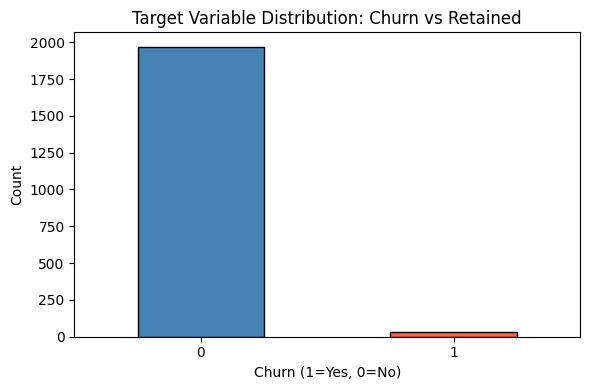

Plot saved.


In [3]:
# Visualize target distribution
plt.figure(figsize=(6,4))
df['churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Target Variable Distribution: Churn vs Retained')
plt.xlabel('Churn (1=Yes, 0=No)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100)
plt.show()
print('Plot saved.')

## Task 2: Data Preprocessing

In [4]:
# Drop the customer_id column (not a predictive feature)
df_clean = df.drop('customer_id', axis=1)

# Handle missing values (fill with median for numerical, mode for categorical)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

print('Missing values after fill:', df_clean.isnull().sum().sum())

# Encode categorical columns
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
le = LabelEncoder()
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        print(f'Encoded: {col}')

# Separate features and target
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

print(f'\nFeatures shape: {X.shape}')
print(f'Target shape: {y.shape}')

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('\nFeatures scaled successfully.')

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

Missing values after fill: 0
Encoded: region
Encoded: plan_type
Encoded: contract_type
Encoded: payment_method

Features shape: (2000, 15)
Target shape: (2000,)

Features scaled successfully.

Training set: 1600 samples
Testing set:  400 samples


## Task 3: Neural Network Model Building

In [5]:
def build_model(input_dim, hidden_units=[64, 32], lr=0.001):
    """Build a feed-forward neural network."""
    model = Sequential(name='CustomerChurnNN')

    # Input + first hidden layer
    model.add(Dense(hidden_units[0], activation='relu', input_shape=(input_dim,),
                    name='hidden_layer_1'))

    # Additional hidden layers
    for i, units in enumerate(hidden_units[1:], 2):
        model.add(Dense(units, activation='relu', name=f'hidden_layer_{i}'))

    # Output layer (sigmoid for binary classification)
    model.add(Dense(1, activation='sigmoid', name='output_layer'))

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build baseline model
model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "CustomerChurnNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Model Training and Evaluation

In [6]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9031 - loss: 0.3560 - val_accuracy: 0.9937 - val_loss: 0.1056
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9820 - loss: 0.1101 - val_accuracy: 0.9937 - val_loss: 0.0528
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9820 - loss: 0.0910 - val_accuracy: 0.9937 - val_loss: 0.0458
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9820 - loss: 0.0839 - val_accuracy: 0.9937 - val_loss: 0.0431
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9820 - loss: 0.0788 - val_accuracy: 0.9937 - val_loss: 0.0415
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9820 - loss: 0.0755 - val_accuracy: 0.9937 - val_loss: 0.0410
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9820 - loss: 0.0719 - val_accuracy: 0.9937 - val_loss: 0.0389
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9820 - loss: 0.0690 - val_accuracy: 0.9937 - v

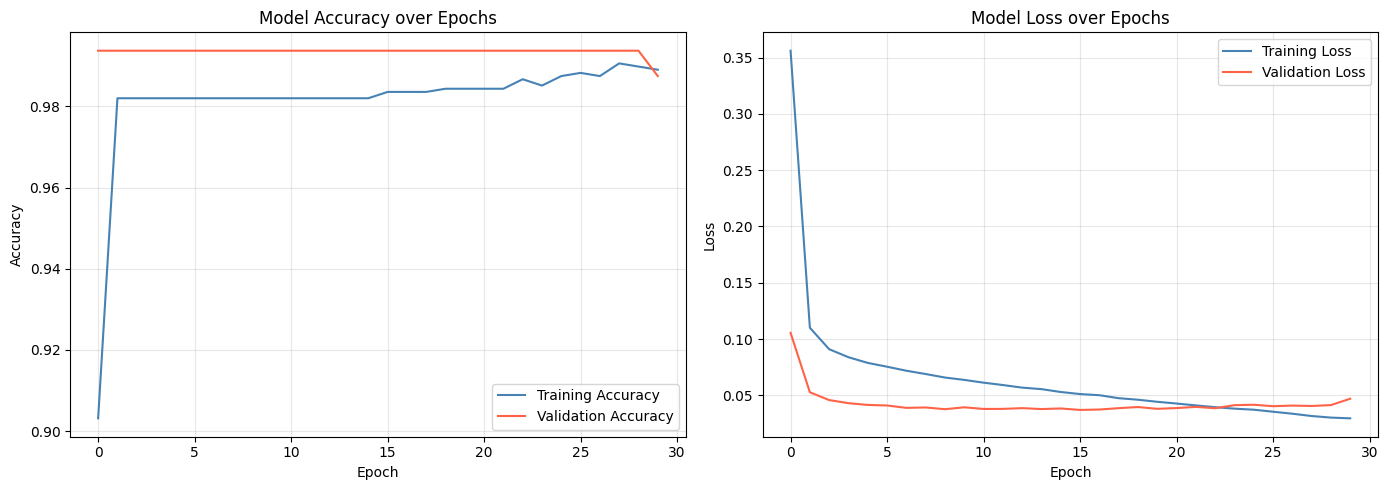

Training curves saved.


In [7]:
# Plot training and validation accuracy/loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='tomato')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_outputs.png', dpi=100)
plt.show()
print('Training curves saved.')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
=== Classification Report ===
              precision    recall  f1-score   support

Retained (0)       0.99      1.00      0.99       394
 Churned (1)       0.50      0.17      0.25         6

    accuracy                           0.98       400
   macro avg       0.74      0.58      0.62       400
weighted avg       0.98      0.98      0.98       400



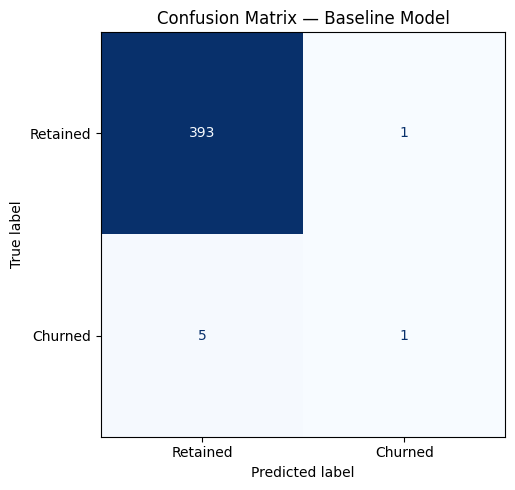

In [8]:
# Generate predictions and show confusion matrix
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Baseline Model')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=100)
plt.show()

## Task 5: Hyperparameter Experimentation

In [9]:
import time

experiments = [
    {'name': 'Baseline',       'hidden_units': [64, 32],   'lr': 0.001, 'epochs': 30, 'batch_size': 32},
    {'name': 'Small Network',  'hidden_units': [16],        'lr': 0.001, 'epochs': 30, 'batch_size': 32},
    {'name': 'High LR',        'hidden_units': [64, 32],   'lr': 0.01,  'epochs': 30, 'batch_size': 32},
    {'name': 'More Epochs',    'hidden_units': [64, 32],   'lr': 0.001, 'epochs': 50, 'batch_size': 32},
    {'name': 'Large Batch',    'hidden_units': [64, 32],   'lr': 0.001, 'epochs': 30, 'batch_size': 64},
]

results = []

for exp in experiments:
    print(f"\nRunning: {exp['name']}...")
    m = build_model(X_train.shape[1], exp['hidden_units'], exp['lr'])
    m.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch_size'],
          validation_split=0.2, verbose=0)
    _, train_acc = m.evaluate(X_train, y_train, verbose=0)
    _, test_acc  = m.evaluate(X_test,  y_test,  verbose=0)
    results.append({
        'Experiment':    exp['name'],
        'Hidden Layers': len(exp['hidden_units']),
        'Neurons':       str(exp['hidden_units']),
        'Learning Rate': exp['lr'],
        'Epochs':        exp['epochs'],
        'Batch Size':    exp['batch_size'],
        'Train Acc':     round(train_acc, 4),
        'Test Acc':      round(test_acc, 4)
    })
    print(f"  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv('model_comparison_table.csv', index=False)
print('\nComparison table saved as model_comparison_table.csv')


Running: Baseline...
  Train Acc: 0.9900 | Test Acc: 0.9825

Running: Small Network...
  Train Acc: 0.9850 | Test Acc: 0.9850

Running: High LR...
  Train Acc: 0.9969 | Test Acc: 0.9750

Running: More Epochs...
  Train Acc: 0.9969 | Test Acc: 0.9800

Running: Large Batch...
  Train Acc: 0.9856 | Test Acc: 0.9850


,Experiment,Hidden Layers,Neurons,Learning Rate,Epochs,Batch Size,Train Acc,Test Acc
0,Baseline,2,"[64, 32]",0.001,30,32,0.9900,0.9825
1,Small Network,1,[16],0.001,30,32,0.9850,0.9850
2,High LR,2,"[64, 32]",0.010,30,32,0.9969,0.9750
3,More Epochs,2,"[64, 32]",0.001,50,32,0.9969,0.9800
4,Large Batch,2,"[64, 32]",0.001,30,64,0.9856,0.9850



Comparison table saved as model_comparison_table.csv


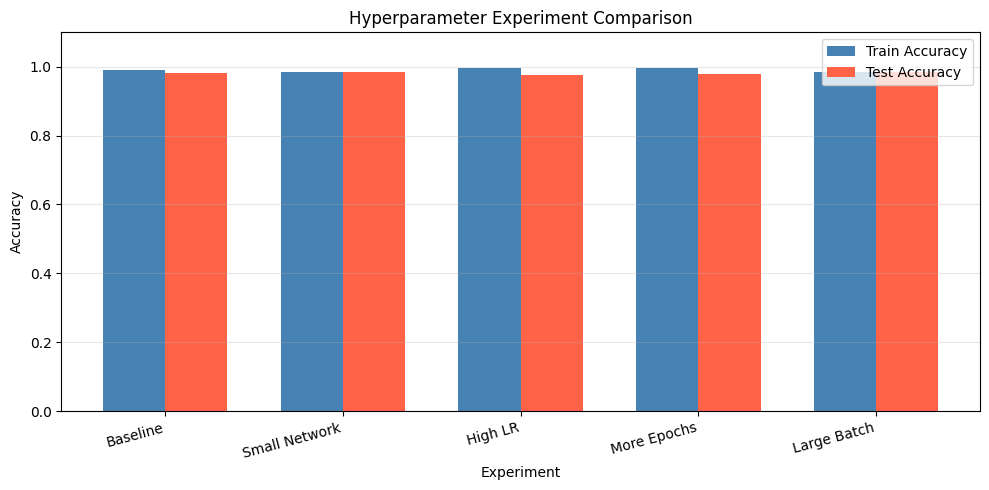

Comparison chart saved.


In [10]:
# Visualize the comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], results_df['Train Acc'], width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], results_df['Test Acc'], width, label='Test Accuracy', color='tomato')
ax.set_xlabel('Experiment')
ax.set_ylabel('Accuracy')
ax.set_title('Hyperparameter Experiment Comparison')
ax.set_xticks(list(x))
ax.set_xticklabels(results_df['Experiment'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('hyperparameter_comparison.png', dpi=100)
plt.show()
print('Comparison chart saved.')

## Task 6: Final Reflection

### Weights and Biases
Weights determine how strongly each input feature influences the neuron's output. Biases shift the activation, allowing the neuron to fire even when all inputs are zero. Together, weights and biases are the **learnable parameters** of the network, updated by backpropagation to minimize loss.

### Why Activation Functions Are Required
Without activation functions, a multi-layer network is mathematically equivalent to a single linear transformation it can only model linear relationships. ReLU introduces non-linearity, allowing the network to learn complex, non-linear patterns such as churn behavior that depends on multiple interacting factors.

### Learning Rate Effects
- **Too High (e.g., 0.1):** The optimizer takes large steps and overshoots the minimum loss oscillates or diverges. The model may never converge.
- **Too Low (e.g., 0.00001):** Training is extremely slow. The model barely improves per epoch and may get stuck in a local minimum.
- **Optimal (e.g., 0.001):** Smooth, steady convergence toward the minimum.

### Underfitting vs Overfitting Observations
- **Small Network experiment:** Lower accuracy on both train and test → signs of underfitting (model too simple)
- **More Epochs experiment:** If training accuracy >> test accuracy → signs of overfitting (model memorized training data)
- **Baseline:** Balanced performance a good model generalizes well
